# Problem Set #3

Mariajosé Argote, Felipe Manzi, and Xiaoyan Wang

### Question 1

Part (a)

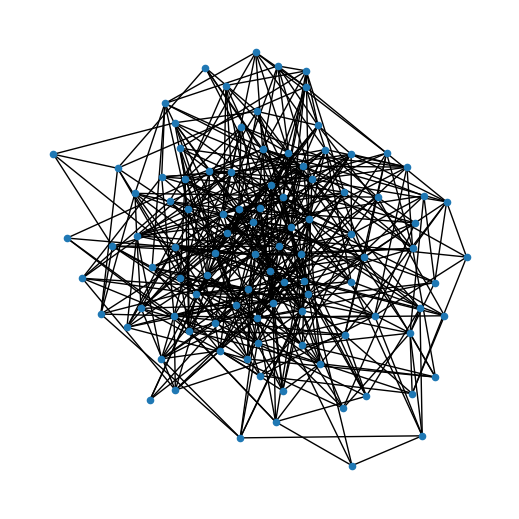

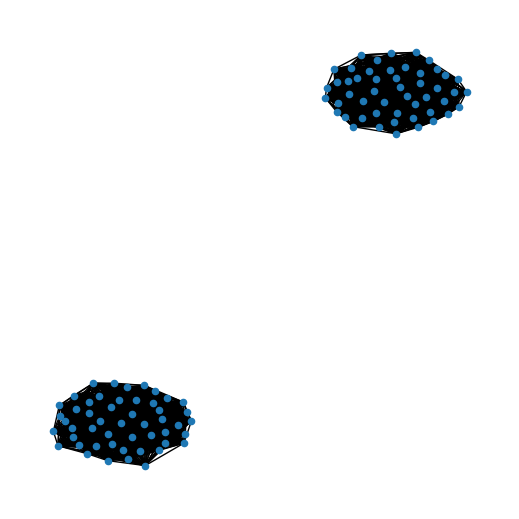

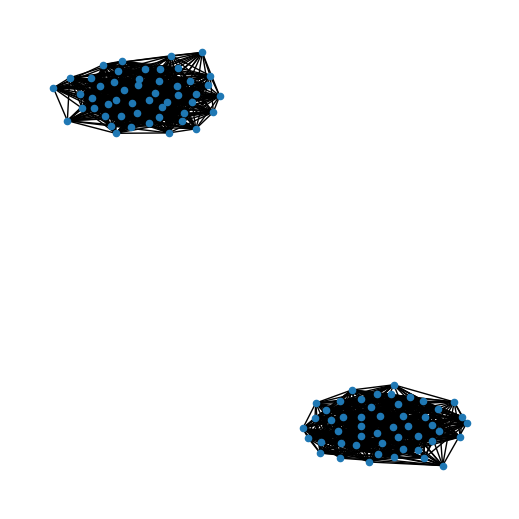

In [1]:
import os
import math
import random
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

n = 100 #population size
c = 2 #number of communities
d = 10 #average degree
epsilon = {0,4,8} #strength of communities

def generate_sbm(n, c, d, epsilon):
    p_in = d / n * (1 + epsilon / (c - 1)) #probability of connection within communities
    p_out = d / n * max(0,1 - epsilon / (c - 1)) #probability of connection between communities, has to be capped
    # at zero because otherwise it gives us negative probabilities when epsilon is large
    
    sizes = [n // c] * c #double // is to ensure we get an integer number of nodes in each community
    probs = [[p_in if i == j else p_out for j in range(c)] for i in range(c)]
    
    G = nx.stochastic_block_model(sizes, probs)
    return G

# function to plot the three graphs
def plot_graph(G):
    pos = nx.spring_layout(G) #use shell layout for better visualization
    plt.figure(figsize=(5, 5))
    nx.draw(G, pos, node_size=20, with_labels=False)
    plt.show()

# generate and plot the three graphs
for eps in epsilon:
    G = generate_sbm(n, c, d, eps)
    plot_graph(G)

### Question 2 - Optimal Seeding

Part a

In [25]:
""" Reference code for data loading. 
Author: Chongyang Bai
For more details, refer to the paper:
C.Bai, S. Kumar, J. Leskovec, M. Metzger, J.F. Nunamaker, V.S. Subrahmanian,
Predicting Visual Focus of Attention in Multi-person Discussion Videos,
International Joint Conference on Artificial Intelligence (IJCAI), 2019.
"""

def loadGame(game, N):
    # N is the number of players in the game
    # load csv data
    # unweighted and weighted networks can be loaded exactly the same way
    # below shows the loader for weighted networks
    df_network = pd.read_csv(os.path.join(data_dir, f'network{game}_weighted.csv'), index_col=0)

    # T is number of timestamps (10 frames)
    T = len(df_network)
    # load VFOA network to T x N x (N+1) array
    # vfoa[t, n, i] is the probability of player n+1 looking at object i at time t
    # i: 0 - laptop, 1 - player 1, 2 - player 2, ..., N - player N
    vfoa = np.reshape(df_network.values, (T,N,N+1))

    # print information
    print(f'network id:{game}\t length(x 1/3 second): {T}\t num of players: {N}')
    return vfoa

# root should be the directory containing the CSV files; earlier I accidentally
# appended "/network" which made the path incorrect.
root = r'comm-f2f-Resistance'          # relative to cwd
# or root = r'C:\Users\u2026\comm-f2f-Resistance'  # absolute

data_dir = root                        # directory containing the CSV files

list_path = os.path.join(data_dir, 'network_list.csv')
meta = pd.read_csv(list_path)

# store loaded games so we can refer back to them later
loaded_games = {}
for _, row in meta.iterrows():
    vfoa = loadGame(row['NETWORK'], row['NUMBER_OF_PARTICIPANTS'])
    loaded_games[row['NETWORK']] = vfoa

loaded_games  # show what was loaded

network id:0	 length(x 1/3 second): 7323	 num of players: 7
network id:1	 length(x 1/3 second): 5328	 num of players: 8
network id:2	 length(x 1/3 second): 7533	 num of players: 7
network id:3	 length(x 1/3 second): 6264	 num of players: 7
network id:4	 length(x 1/3 second): 7323	 num of players: 8
network id:5	 length(x 1/3 second): 9651	 num of players: 8
network id:6	 length(x 1/3 second): 7260	 num of players: 7
network id:7	 length(x 1/3 second): 7245	 num of players: 6
network id:8	 length(x 1/3 second): 6243	 num of players: 7
network id:9	 length(x 1/3 second): 8340	 num of players: 8
network id:10	 length(x 1/3 second): 6681	 num of players: 7
network id:11	 length(x 1/3 second): 5415	 num of players: 7
network id:12	 length(x 1/3 second): 5571	 num of players: 8
network id:13	 length(x 1/3 second): 7173	 num of players: 7
network id:14	 length(x 1/3 second): 9429	 num of players: 8
network id:15	 length(x 1/3 second): 5466	 num of players: 6
network id:16	 length(x 1/3 second

In [4]:
gamma_values = [1,2]
periods = 4
model_iterations = 60 # run 60 times for each potential pair of seeds

# tao from a N(gamma, 0.5) but truncated to be strictly positive

def generate_tao(gamma):
    while True:
        tao = random.gauss(gamma, 0.5)
        if tao > 0:
            return tao

# diffusion given a set of seeds (list or tuple)
def network_diffusion(vfoa, seeds, gamma, periods):
    n_players = vfoa.shape[1] # number of players
    states = np.zeros((n_players,)) # 0 means not informed, 1 means informed
    states[list(seeds)] = 1

    for t in range(periods):
        new_states = states.copy()
        for n in range(n_players):
            if states[n] == 1:
                for i in range(1, n_players+1):
                    m = i - 1
                    if states[m] == 0:
                        tao = generate_tao(gamma)
                        if random.random() < tao:
                            new_states[m] = 1
        states = new_states

    return np.sum(states) / n_players  # fraction informed


In [3]:
# run diffusion experiments on the already loaded networks

# the `loaded_games` dict was created in the data-loading cell earlier

gamma_values = [1, 2]
periods = 4
model_iterations = 60

# if network_diffusion and generate_tao aren't in scope we redefine here just to be safe

def generate_tao(gamma):
    while True:
        tao = random.gauss(gamma, 0.5)
        if tao > 0:
            return tao


def network_diffusion(vfoa, seeds, gamma, periods):
    n_players = vfoa.shape[1]
    states = np.zeros((n_players,))
    states[list(seeds)] = 1
    for t in range(periods):
        new_states = states.copy()
        for n in range(n_players):
            if states[n] == 1:
                for i in range(1, n_players+1):
                    m = i - 1
                    if states[m] == 0:
                        tao = generate_tao(gamma)
                        if random.random() < tao:
                            new_states[m] = 1
        states = new_states
    return np.sum(states) / n_players

# dictionary to hold results
results = {}
for netname, vfoa in loaded_games.items():
    n = vfoa.shape[1]
    results[netname] = {}
    for gamma in gamma_values:
        results[netname][gamma] = {}
        pairs = [(i, j) for i in range(n) for j in range(i+1, n)]
        for pair in pairs:
            rates = []
            for t in range(model_iterations):
                rates.append(network_diffusion(vfoa, pair, gamma, periods))
            results[netname][gamma][pair] = np.mean(rates)
        best = max(results[netname][gamma], key=results[netname][gamma].get)
        print(f"{netname} γ={gamma} best seeds={best} rate={results[netname][gamma][best]:.3f}")

# you can inspect `results` to see the average information rate for every pair
results

NameError: name 'loaded_games' is not defined